# 다중분류 (분류 종류가 3개 이상)

### 두 파일의 차이점
### 02:정답이 두 개(생존/사망)인 이진 분류 / 03:정답이 세 개(꽃의 종류 3가지)인 다중 분류
- 비교 항목 : 첫 번째 파일 (02번) / 두 번째 파일 (03번)
- 주제 : 타이타닉 생존 예측 / 붓꽃(Iris) 품종 예측
- 분류 종류 : 이진 분류 (0, 1) / 다중 분류 (0, 1, 2)
- 출력층 설정 : Dense(1) + sigmoid / Dense(3) + softmax
- 손실 함수 : binary_crossentropy / categorical_crossentropy

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("https://raw.githubusercontent.com/haram4th/ADsP/main/iris3.csv")
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
data['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


<Axes: >

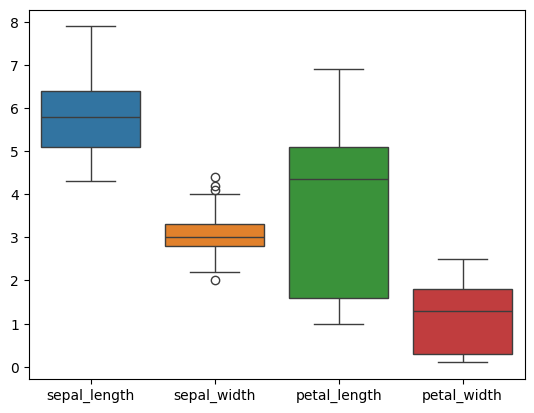

In [4]:
sns.boxplot(data)

In [5]:
X = data.drop('species', axis=1)
y = data['species']

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [9]:
y_train

22         Iris-setosa
15         Iris-setosa
65     Iris-versicolor
11         Iris-setosa
42         Iris-setosa
            ...       
71     Iris-versicolor
106     Iris-virginica
14         Iris-setosa
92     Iris-versicolor
102     Iris-virginica
Name: species, Length: 120, dtype: str

## 데이터 전처리

다중 분류(여러 개 중 하나 고르기)를 할 때는 이전 파일에는 없던 매우 중요한 단계가 추가됩니다.

### 레이블 인코딩 (Label Encoding)
꽃 이름(문자)을 컴퓨터가 이해하도록 숫자(0, 1, 2)로 바꿉니다.

### 원-핫 인코딩 (One-Hot Encoding)

중요 개념: 컴퓨터는 0, 1, 2라는 숫자를 보고 "2가 0보다 크네?"라고 오해할 수 있습니다.

이를 방지하기 위해 [1, 0, 0], [0, 1, 0], [0, 0, 1] 처럼 자기 자리만 1이고 나머지는 0인 목록으로 만드는 과정입니다. 이 파일에서 to_categorical 함수가 이 역할을 합니다.

# 종속변수 y를  label encoder로 변환하기
* 딥러닝에서 다중분류를 할 때 종속변수 y는 대부분 label encoding
* one-hot encoding을 할 경우 메모리 사용량이 많아지기 때문

In [10]:
from sklearn.preprocessing import LabelEncoder

In [11]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [12]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [13]:
y_train

array([0, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 0, 0, 1, 2, 2, 1, 2, 1, 2,
       1, 0, 2, 1, 0, 0, 0, 1, 2, 0, 0, 0, 1, 0, 1, 2, 0, 1, 2, 0, 2, 2,
       1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 2, 2, 1,
       0, 0, 2, 2, 0, 0, 0, 1, 2, 0, 2, 2, 0, 1, 1, 2, 1, 2, 0, 2, 1, 2,
       1, 1, 1, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 2, 0, 2, 0, 1, 2, 2, 1, 2,
       1, 1, 2, 2, 0, 1, 2, 0, 1, 2])

### 여기까지 전처리 끝

# 모델 구축 - 텐서플로우로 다중분류 분석하기

In [14]:
from keras.models import Sequential
from keras.layers import Dense, Input

In [15]:
len(np.unique(y_train))

3

### 모델 구축 (다중 분류용 설정)

모델을 쌓는 것은 이전과 비슷하지만, 끝부분이 완전히 다릅니다.

은닉층: 이전처럼 Dense 층을 쌓고 activation='relu'를 씁니다.

출력층 (Output Layer) ⭐⭐⭐:

노드 수: 분류하고 싶은 종류가 3개이므로 Dense(3)으로 설정합니다. (이진 분류는 1이었죠?)

활성화 함수: activation='softmax'를 사용합니다.

Softmax란?: 출력된 숫자들의 총합을 1(100%)로 만들어, "A일 확률 70%, B일 확률 20%, C일 확률 10%" 식으로 확률을 보여주는 함수입니다.

In [30]:
# 모델 구축하기
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(len(np.unique(y_train)), activation='softmax'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │              15 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
  * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
  * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.3333 - loss: 2.6938 - val_accuracy: 0.3333 - val_loss: 2.2926
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3333 - loss: 2.2208 - val_accuracy: 0.3333 - val_loss: 1.8763
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3333 - loss: 1.8082 - val_accuracy: 0.3333 - val_loss: 1.5123
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3333 - loss: 1.4476 - val_accuracy: 0.3333 - val_loss: 1.2366
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.3333 - loss: 1.1831 - val_accuracy: 0.3333 - val_loss: 1.1166
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3833 - loss: 1.0818 - val_accuracy: 0.3667 - val_loss: 1.0888
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.3750 - loss: 1.0748 - val_accuracy: 0.3000 - val_loss: 1.0954
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.3417 - loss: 1.0690 - val_accuracy: 0.3000 - val_loss

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9583 - loss: 0.4778 - val_accuracy: 1.0000 - val_loss: 0.4595
Epoch 51/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.9667 - loss: 0.4627 - val_accuracy: 1.0000 - val_loss: 0.4373
Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9667 - loss: 0.4406 - val_accuracy: 0.9667 - val_loss: 0.4207
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9500 - loss: 0.4250 - val_accuracy: 0.9667 - val_loss: 0.4056
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9667 - loss: 0.4128 - val_accuracy: 1.0000 - val_loss: 0.3872
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9500 - loss: 0.3936 - val_accuracy: 0.9667 - val_loss: 0.3710
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9583 - loss: 0.3771 - val_accuracy: 1.0000 - val_loss: 0.3562
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.9583 - loss: 0.3662 - val_accuracy: 1.0000 - val_loss: 0.34

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
[[1.28536914e-02 8.98676455e-01 8.84698629e-02]
 [9.88674700e-01 1.11136204e-02 2.11717692e-04]
 [3.28611844e-04 2.34767403e-02 9.76194561e-01]
 [1.53717827e-02 7.61515439e-01 2.23112822e-01]
 [8.69918521e-03 8.78115833e-01 1.13185018e-01]
 [9.78560627e-01 2.08774935e-02 5.61906782e-04]
 [3.44089232e-02 9.24484313e-01 4.11066972e-02]
 [1.95943704e-03 8.02989453e-02 9.17741597e-01]
 [9.03676543e-03 4.60738569e-01 5.30224741e-01]
 [1.72281191e-02 9.42987978e-01 3.97838838e-02]
 [5.70301479e-03 2.33510971e-01 7.60786057e-01]
 [9.76106882e-01 2.33758427e-02 5.17178036e-04]
 [9.88155484e-01 1.16610415e-02 1.83491007e-04]
 [9.77808595e-01 2.17302702e-02 4.61126794e-04]
 [9.89133894e-01 1.06285382e-02 2.37590633e-04]
 [1.38908653e-02 8.29773307e-01 1.56335875e-01]
 [1.11807522e-03 3.38809639e-02 9.65000987e-01]
 [1.64255463e-02 9.37372029e-01 4.62023951e-02]
 [1.76645704e-02 8.20744097e-01 1.61591291e-01]
 [1.23755017e-03 3.63621227e-02 9.62400258e-01]
 

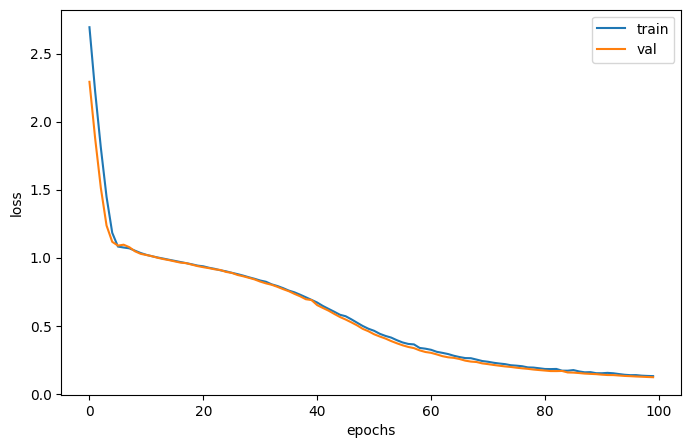

,y_test,pred
0,1,1
1,0,0
2,2,2
3,1,1
4,1,1
5,0,0
6,1,1
7,2,2
8,1,2
9,1,1


In [17]:
model.compile(loss="sparse_categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(X_train, y_train, epochs=100, batch_size=16,
                   validation_data=(X_test, y_test))
pred = model.predict(X_test)
print(pred)
pred = pred.argmax(axis=1)
result = pd.DataFrame(dict(y_test = y_test, pred=pred))
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()
result

# One-hot Encoding 버전

In [18]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y, test_size=0.2, random_state=42)

In [19]:
y_train2

22         Iris-setosa
15         Iris-setosa
65     Iris-versicolor
11         Iris-setosa
42         Iris-setosa
            ...       
71     Iris-versicolor
106     Iris-virginica
14         Iris-setosa
92     Iris-versicolor
102     Iris-virginica
Name: species, Length: 120, dtype: str

In [20]:
y_test2

73     Iris-versicolor
18         Iris-setosa
118     Iris-virginica
78     Iris-versicolor
76     Iris-versicolor
31         Iris-setosa
64     Iris-versicolor
141     Iris-virginica
68     Iris-versicolor
82     Iris-versicolor
110     Iris-virginica
12         Iris-setosa
36         Iris-setosa
9          Iris-setosa
19         Iris-setosa
56     Iris-versicolor
104     Iris-virginica
69     Iris-versicolor
55     Iris-versicolor
132     Iris-virginica
29         Iris-setosa
127     Iris-virginica
26         Iris-setosa
128     Iris-virginica
131     Iris-virginica
145     Iris-virginica
108     Iris-virginica
143     Iris-virginica
45         Iris-setosa
30         Iris-setosa
Name: species, dtype: str

In [21]:
y_train2 = pd.get_dummies(y_train2)
y_train2

,Iris-setosa,Iris-versicolor,Iris-virginica
22,True,False,False
15,True,False,False
65,False,True,False
11,True,False,False
42,True,False,False
...,...,...,...
71,False,True,False
106,False,False,True
14,True,False,False
92,False,True,False


In [22]:
y_test2 = pd.get_dummies(y_test2)
y_test2

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [23]:
y_train2.shape[1]

3

In [24]:
from keras.models import Sequential
from keras.layers import Input, Dense

In [25]:
model = Sequential()
model.add(Input(shape=(X_train2.shape[1],)))
model.add(Dense(16, activation='relu'))
model.add(Dense(8, activation='relu'))
model.add(Dense(4, activation='relu'))
model.add(Dense(y_train2.shape[1], activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 16)                  │              80 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 4)                   │              36 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │              15 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 267 (1.04 KB)

 Trainable params: 267 (1.04 KB)

 Non-trainable params: 0 (0.00 B)

* 다중분류의 경우 사용하는 loss
  * categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 one-hot encoding된 경우
  * sparse_categorical_crossentropy: 종속변수 클래스가 3개 이상인 경우이고 label encoding 된 경우

In [26]:
model.compile(loss="categorical_crossentropy",
             optimizer='adam',
             metrics=['accuracy'])
history = model.fit(X_train2, y_train2, epochs=100, batch_size=16,
                   validation_data=(X_test2, y_test2))
pred2 = model.predict(X_test2)
print(pred2)
pred2 = pred2.argmax(axis=1)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 101ms/step - accuracy: 0.3417 - loss: 1.9880 - val_accuracy: 0.3000 - val_loss: 1.8397
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.3417 - loss: 1.5507 - val_accuracy: 0.3000 - val_loss: 1.4517
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3417 - loss: 1.2769 - val_accuracy: 0.3000 - val_loss: 1.2195
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.3417 - loss: 1.1293 - val_accuracy: 0.3000 - val_loss: 1.1209
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4333 - loss: 1.0839 - val_accuracy: 0.6000 - val_loss: 1.0957
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6500 - loss: 1.0861 - val_accuracy: 0.6333 - val_loss: 1.0976
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6583 - loss: 1.0816 - val_accuracy: 0.6000 - val_loss: 1.0915
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.6167 - loss: 1.0697 - val_accuracy: 0.4333 - val_loss

Epoch 52/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6500 - loss: 0.8123 - val_accuracy: 0.6333 - val_loss: 0.8141
Epoch 53/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6000 - loss: 0.8046 - val_accuracy: 0.5333 - val_loss: 0.8041
Epoch 54/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.5750 - loss: 0.7998 - val_accuracy: 0.4667 - val_loss: 0.7972
Epoch 55/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5500 - loss: 0.7941 - val_accuracy: 0.5333 - val_loss: 0.7925
Epoch 56/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5667 - loss: 0.7881 - val_accuracy: 0.5333 - val_loss: 0.7887
Epoch 57/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5833 - loss: 0.7832 - val_accuracy: 0.4667 - val_loss: 0.7797
Epoch 58/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5750 - loss: 0.7784 - val_accuracy: 0.4667 - val_loss: 0.7751
Epoch 59/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6083 - loss: 0.7734 - val_accuracy: 0.4667 - v

In [27]:
y_test2

,Iris-setosa,Iris-versicolor,Iris-virginica
73,False,True,False
18,True,False,False
118,False,False,True
78,False,True,False
76,False,True,False
31,True,False,False
64,False,True,False
141,False,False,True
68,False,True,False
82,False,True,False


In [28]:
result2 = pd.DataFrame(dict(y_test2 = y_test2, pred2=pred2))

ValueError: Data must be 1-dimensional, got ndarray of shape (30, 3) instead

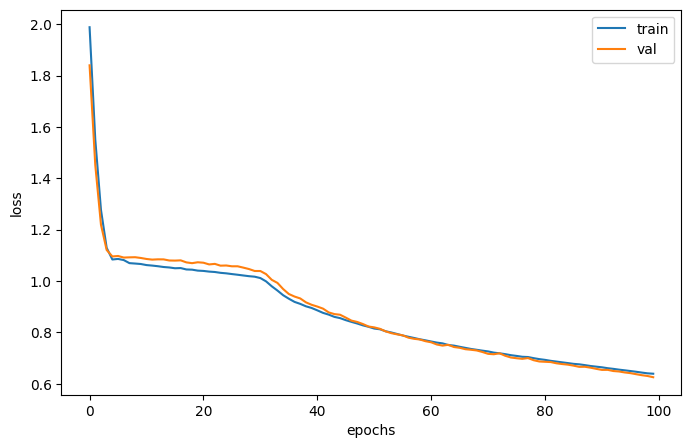

In [29]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()